# GP-KANの学習安定化方法調査: 比較用SparseGP

## 0.背景/目的
本notebookでは、GP-KANの変分ベイズ推定による学習結果を評価する：

### モデル構成
- **ネットワーク構造**: 1層GP(入力1次元 → 出力1次元)
- **誘導点数**: 各GPあたり10点

## 1.問題設定

真の関数: フーリエ級数
$$f(t) = \frac{4}{\pi} \sum_{n=1}^{N} \frac{1}{n} \sin(nt), \quad n = 1, 3, 5, \ldots, \quad t \in [0, 1]$$
※$N=15$

データ: 
- 合計1,000件: 学習700件/検証150件/評価150件
- tは$(-1,1)$から一様ランダムサンプリング

モデル:
- 2層のGPKAN: 入力1次元/中間層1次元/出力1次元
    - それぞれのGPを(<1層目のindex>,<2層目のindex>)形式で表すことにすると、GPKANは$(0,0),(1,0)$の2つのGPで構成



## 2.メイン処理
本ノートブックのメイン処理を実行する。実行順は以下の通り：

2-1.データセット作成

2-2.GPKANの学習

2-3.精度評価

2-4.学習中のカーネル行列ランク可視化

### 2-1.データセット作成

In [ ]:
# 初期設定: 必要なライブラリをインポートし、パスを設定
import os
import sys

sys.path.append("../../")
import japanize_matplotlib
import torch.utils.data
from lib import model as gplib
from lib import runner
from torch.utils.data import DataLoader

In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset


# Generate synthetic data with Fourier series function
def set_seed(seed=42):
    """完全な再現性のための乱数シード設定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def worker_init_fn(worker_id):
    """DataLoaderワーカープロセス用の乱数シード設定"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(42)  # 全体の乱数シード設定
num_samples = 1000

# Generate random input points t from [-1, 1]
t = np.random.uniform(-1, 1, num_samples)


# Compute target values: f(t) = (4/π) * Σ(1/n * sin(nt)) for odd n up to N=15
def fourier_series(t, N=15):
    result = np.zeros_like(t)
    for n in range(1, N + 1, 2):  # odd numbers only: 1, 3, 5, 7, 9, 11, 13, 15
        result += (1 / n) * np.sin(n * t)
    return (4 / np.pi) * result


targets = fourier_series(t, N=15)

# Reshape inputs (t is 1D, but we need it as 2D for compatibility)
inputs = t.reshape(-1, 1)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(inputs)
y_tensor = torch.FloatTensor(targets).reshape(-1, 1)

# Split data into train, validation, and test sets
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size : train_size + val_size]
y_val = y_tensor[train_size : train_size + val_size]

X_test = X_tensor[train_size + val_size :]
y_test = y_tensor[train_size + val_size :]

# データを昇順にソート（X_testとy_testを対応を保ちながら）
sorted_indices = torch.argsort(X_test.squeeze())
X_test = X_test[sorted_indices]
y_test = y_test[sorted_indices]

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create dataloaders
batch_size = 32

In [ ]:
# Create dataloaders with reproducible worker processes
generator = torch.Generator()
generator.manual_seed(42)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)

Train samples: 700
Validation samples: 150
Test samples: 150


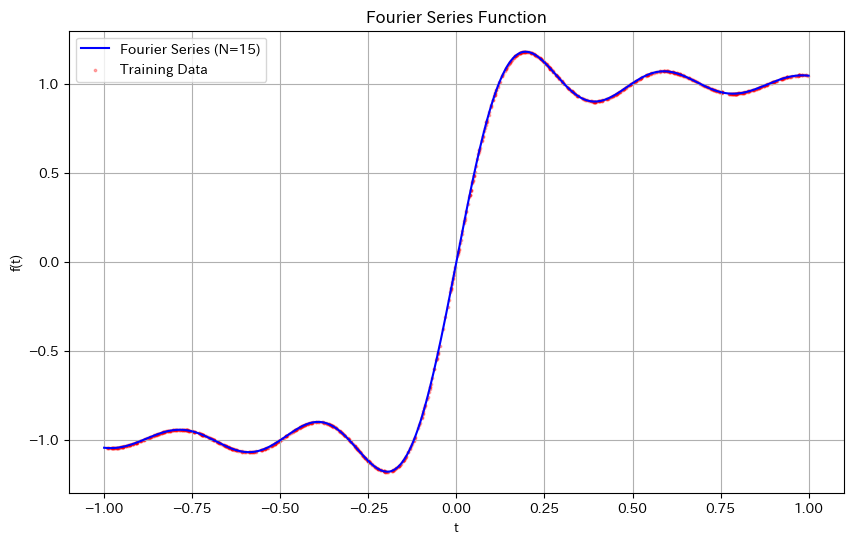

In [ ]:
# サンプル数確認
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Fourier級数関数のプロット
t_plot = np.linspace(-1, 1, 1000)
y_plot = fourier_series(t_plot, N=15)
plt.figure(figsize=(10, 6))
plt.plot(t_plot, y_plot, "b-", label="Fourier Series (N=15)")
plt.scatter(t, targets, alpha=0.3, s=3, c="red", label="Training Data")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Fourier Series Function")
plt.legend()
plt.grid(True)
plt.show()

### 2-2.モデル学習

In [ ]:
import time

import gpytorch
import torch.nn as nn


# Define the Sparse Variational GP model
class SparseVariationalGP(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )
        super(SparseVariationalGP, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# Initialize inducing points
num_inducing = 10
inducing_points = torch.linspace(-1, 1, num_inducing).reshape(-1, 1)

# Create model and likelihood
model = SparseVariationalGP(inducing_points)
likelihood = gpytorch.likelihoods.GaussianLikelihood()

# Training
model.train()
likelihood.train()

# Use Adam optimizer
optimizer = torch.optim.Adam(
    [
        {"params": model.parameters()},
        {"params": likelihood.parameters()},
    ],
    lr=0.01,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.8, patience=20, verbose=True
)
# Loss function for variational GP
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_dataset))

num_epochs = 200
start_time = time.time()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in train_dataloader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = -mll(output, y_batch.squeeze())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Calculate average epoch loss
    avg_epoch_loss = epoch_loss / len(train_dataloader)

    # Step the scheduler with the loss
    scheduler.step(avg_epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_epoch_loss:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

print("Training completed!")

/Users/daisuke_takehara/Desktop/workdir_gpkan/.venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 50/200, Loss: -0.5431
Epoch 100/200, Loss: -0.8064
Epoch 150/200, Loss: -1.0028
Epoch 200/200, Loss: -1.1869
Training time: 27.20 seconds
Training completed!


In [ ]:
# Model evaluation
model.eval()
likelihood.eval()

# Make predictions on test data
with torch.no_grad():
    test_predictions = likelihood(model(X_test))
    test_mean = test_predictions.mean

# Calculate RMSE
rmse = torch.sqrt(torch.mean((test_mean - y_test.squeeze()) ** 2))
print(f"Test RMSE: {rmse.item():.4f}")

Test RMSE: 0.0298


## InducingPointsの可視化

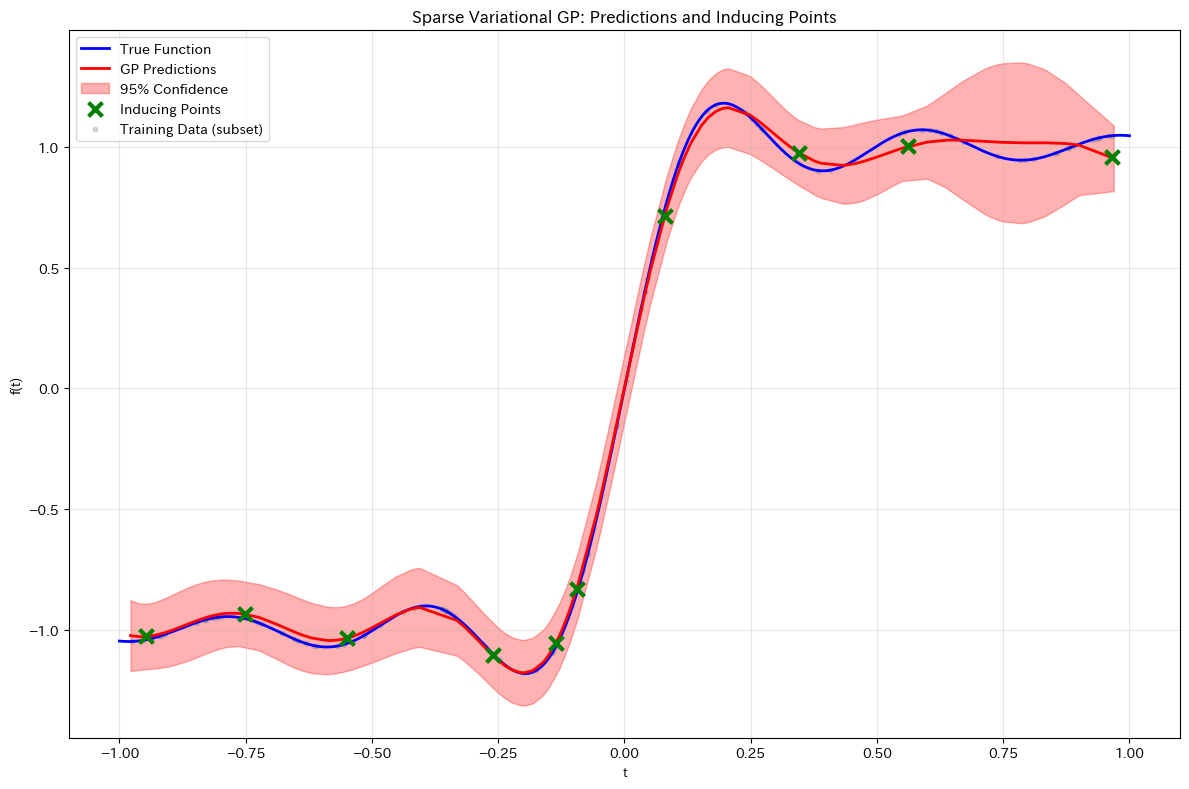

Number of inducing points: 10
Inducing point locations: [-0.9471336  -0.750849   -0.54905593 -0.26094598 -0.13613106 -0.09459896
  0.07932405  0.3465951   0.56185114  0.96438617]


In [ ]:
# Visualize inducing points
plt.figure(figsize=(12, 8))

# Plot true function
t_plot = np.linspace(-1, 1, 1000)
y_plot = fourier_series(t_plot, N=15)
plt.plot(t_plot, y_plot, "b-", linewidth=2, label="True Function")

# Plot test predictions
plt.plot(
    X_test.squeeze().numpy(),
    test_mean.numpy(),
    "r-",
    linewidth=2,
    label="GP Predictions",
)

# Plot confidence intervals
with torch.no_grad():
    lower, upper = test_predictions.confidence_region()
plt.fill_between(
    X_test.squeeze().numpy(),
    lower.numpy(),
    upper.numpy(),
    alpha=0.3,
    color="red",
    label="95% Confidence",
)

# Plot inducing points
inducing_locations = model.variational_strategy.inducing_points.detach().numpy()
# Get function values at inducing points for visualization
with torch.no_grad():
    inducing_predictions = model(model.variational_strategy.inducing_points)
    inducing_mean = likelihood(inducing_predictions).mean.numpy()

plt.scatter(
    inducing_locations,
    inducing_mean,
    c="green",
    s=100,
    marker="x",
    linewidths=3,
    label="Inducing Points",
    zorder=5,
)

# Plot original training data (subset for clarity)
train_indices = np.random.choice(len(X_train), 100, replace=False)
plt.scatter(
    X_train[train_indices].numpy(),
    y_train[train_indices].numpy(),
    alpha=0.3,
    s=10,
    c="gray",
    label="Training Data (subset)",
)

plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Sparse Variational GP: Predictions and Inducing Points")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of inducing points: {len(inducing_locations)}")
print(f"Inducing point locations: {inducing_locations.flatten()}")

## 3. GP-KANの実装 (GPyTorch版)

ここでは、gpytorch.models.ApproximateGPを用いてGP-KANを実装します。

### GP-KANの制約条件：
1. GP-KANはそれぞれのnodeで活性化関数(1次元のガウス過程)による非線形変換を行う
2. GP-KANはそれぞれのedgeでは総和を計算し出力(学習しない)

### アーキテクチャ：
- 入力層: 1次元
- 中間層: 1次元 (GPノード)
- 出力層: 1次元
- GPが2つ: (0,0), (1,0) の構成

In [ ]:
import gpytorch
import torch
import torch.nn as nn


class GPKANNode(gpytorch.models.ApproximateGP):
    """
    GP-KANの単一ノード（活性化関数としてのガウス過程）
    制約1を満たす：各nodeで1次元ガウス過程による非線形変換
    """
    def __init__(self, inducing_points, input_dim=1):
        # 変分分布の設定
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        # 変分戦略の設定（誘導点の学習を有効化）
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )
        super(GPKANNode, self).__init__(variational_strategy)
        
        # 平均関数（定数平均）
        self.mean_module = gpytorch.means.ConstantMean()
        # 共分散関数（スケールされたRBFカーネル）
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class GPKAN(nn.Module):
    """
    GP-KAN: GPノードをedgeで接続するネットワーク
    制約1,2を満たす実装
    """
    def __init__(self, layer_sizes, num_inducing_points=10):
        super(GPKAN, self).__init__()
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.num_inducing_points = num_inducing_points
        
        # GP-KANのGPノードを格納するリスト
        self.gp_nodes = nn.ModuleList()
        self.likelihoods = nn.ModuleList()
        
        # 各層のGPノードを作成
        for layer_idx in range(self.num_layers):
            layer_gps = nn.ModuleList()
            layer_likelihoods = nn.ModuleList()
            
            input_size = layer_sizes[layer_idx]
            output_size = layer_sizes[layer_idx + 1]
            
            # 出力ノードごとにGPを作成
            for output_idx in range(output_size):
                # 誘導点の初期化（入力範囲に基づく）
                inducing_points = torch.linspace(-1, 1, num_inducing_points).reshape(-1, 1)
                
                # GPノードの作成
                gp_node = GPKANNode(inducing_points, input_dim=input_size)
                likelihood = gpytorch.likelihoods.GaussianLikelihood()
                
                layer_gps.append(gp_node)
                layer_likelihoods.append(likelihood)
            
            self.gp_nodes.append(layer_gps)
            self.likelihoods.append(layer_likelihoods)

    def forward(self, x):
        """
        順伝播処理
        制約2を満たす：edgeでは総和を計算（学習パラメータなし）
        """
        current_input = x
        
        for layer_idx in range(self.num_layers):
            layer_outputs = []
            
            # 各出力ノードに対してGP計算
            for output_idx in range(len(self.gp_nodes[layer_idx])):
                gp_node = self.gp_nodes[layer_idx][output_idx]
                
                # 入力が複数次元の場合は総和を取る（制約2）
                if current_input.dim() > 2 or (current_input.dim() == 2 and current_input.size(1) > 1):
                    # 複数の入力を総和（edgeの処理）
                    summed_input = current_input.sum(dim=1, keepdim=True)
                else:
                    summed_input = current_input
                
                # GPによる非線形変換（制約1）
                gp_output = gp_node(summed_input)
                layer_outputs.append(gp_output)
            
            # 次の層への入力として、各GPの出力を結合
            if len(layer_outputs) == 1:
                current_input = layer_outputs[0].mean.unsqueeze(-1)
            else:
                # 複数出力の場合は横に結合
                means = [output.mean.unsqueeze(-1) for output in layer_outputs]
                current_input = torch.cat(means, dim=1)
        
        return layer_outputs[-1]  # 最終層の出力を返す

    def get_mll_loss(self, x, y, layer_idx=None):
        """
        変分下界（ELBO）損失の計算
        """
        total_loss = 0
        num_data = x.size(0)
        
        # 指定された層のみ、または全層の損失を計算
        if layer_idx is not None:
            layers_to_process = [layer_idx]
        else:
            layers_to_process = range(self.num_layers)
        
        for l_idx in layers_to_process:
            for output_idx, (gp_node, likelihood) in enumerate(zip(self.gp_nodes[l_idx], self.likelihoods[l_idx])):
                mll = gpytorch.mlls.VariationalELBO(likelihood, gp_node, num_data=num_data)
                
                # 入力の準備
                if l_idx == 0:
                    gp_input = x
                else:
                    # 前の層の出力を使用（簡単のため、ここでは入力をそのまま使用）
                    gp_input = x
                
                if gp_input.dim() > 2 or (gp_input.dim() == 2 and gp_input.size(1) > 1):
                    gp_input = gp_input.sum(dim=1, keepdim=True)
                
                # GP出力の取得
                gp_output = gp_node(gp_input)
                
                # 最終層の場合はyと比較、それ以外は中間表現として扱う
                if l_idx == self.num_layers - 1:
                    target = y.squeeze()
                else:
                    # 中間層の場合、自己教師ありタスクまたはスキップ
                    continue
                
                # 変分下界の計算
                loss = -mll(gp_output, target)
                total_loss += loss
        
        return total_loss

    def train_mode(self):
        """トレーニングモードに設定"""
        self.train()
        for layer_gps in self.gp_nodes:
            for gp_node in layer_gps:
                gp_node.train()
        for layer_likelihoods in self.likelihoods:
            for likelihood in layer_likelihoods:
                likelihood.train()

    def eval_mode(self):
        """評価モードに設定"""
        self.eval()
        for layer_gps in self.gp_nodes:
            for gp_node in layer_gps:
                gp_node.eval()
        for layer_likelihoods in self.likelihoods:
            for likelihood in layer_likelihoods:
                likelihood.eval()


# GPKANモデルの作成
print("Creating GP-KAN model...")
layer_sizes = [1, 1, 1]  # 入力1次元 -> 中間1次元 -> 出力1次元
num_inducing = 10

gpkan_model = GPKAN(layer_sizes, num_inducing_points=num_inducing)
print(f"GP-KAN model created with layer sizes: {layer_sizes}")
print(f"Number of inducing points per GP: {num_inducing}")
print(f"Total number of GPs: {sum(len(layer) for layer in gpkan_model.gp_nodes)}")

### 3-1. GP-KANモデルの学習